=== ENHANCED SYNTHETIC VIX PIPELINE (STACKING + WALK-FORWARD) ===

--- Step 1: Data Collection & Pre-computation ---
--> CHECKPOINT: Base data loaded. S&P500 shape: (12026, 5), VIX shape: (8993, 1)
Using FRED API Key for data download.

--> CHECKPOINT: External data collection complete. 2 sources loaded.
    - T10Y2Y: Loaded data from 1978-01-01 to 2025-09-15
    - CPIAUCSL: Loaded data from 1978-01-01 to 2025-09-15
Fitting enhanced GARCH model...
Fitting enhanced regime switching model...


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--> CHECKPOINT: GARCH and Regime models fitted.

--- Step 2: Feature Engineering (Full Dataset) ---

--- Step 2a: Feature Analysis & Engineering ---
Analyzing for feature correlations above 0.9...
  --> High Correlation: 'GARCH_vol_lag1' and 'GARCH_vol' (0.98)
  --> High Correlation: 'Realized_Vol_10d' and 'Realized_Vol_5d' (0.90)
  --> High Correlation: 'Realized_Vol_21d' and 'Realized_Vol_10d' (0.92)
  --> High Correlation: 'YZ_Volatility' and 'Realized_Vol_10d' (0.91)
  --> High Correlation: 'YZ_Volatility' and 'Realized_Vol_21d' (0.98)
  --> High Correlation: 'Regime_1_Prob' and 'Regime_0_Prob' (1.00)
Engineering new interaction features...
  --> Created 'GARCH_x_YieldCurve'

--- DATA INSPECTION @ Before Feature Cleaning (dropna) ---
Shape: (8993, 28)
                Column     NaN %  Start Date    End Date
18   Rolling_Skew_126d  1.401090  1990-07-02  2025-09-16
19   Rolling_Kurt_126d  1.401090  1990-07-02  2025-09-16
17   Realized_Vol_126d  1.401090  1990-07-02  2025-09-16
16    

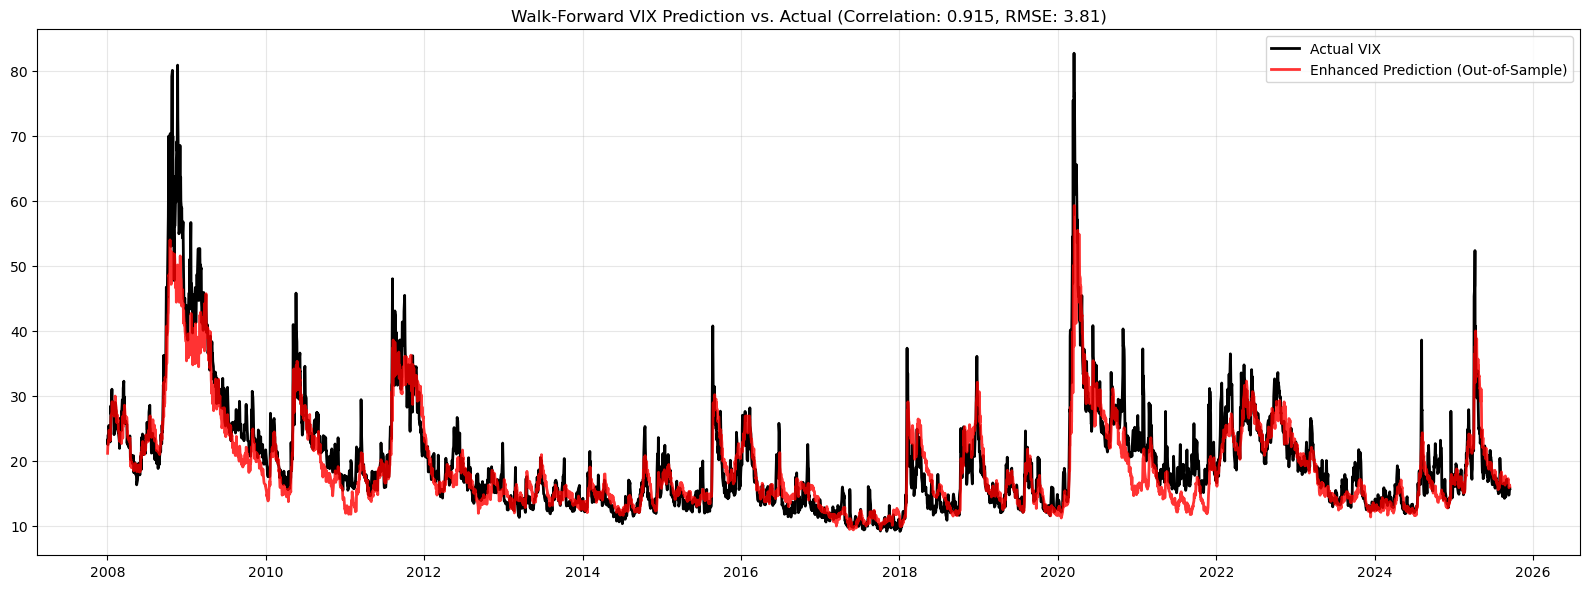


--- Step 5: Generate Final Synthetic VIX for Backfill Period ---
Retraining models on all available data for final backfill...
Training stacking ensemble...
  Generating out-of-fold predictions for meta-model...
  Training final base models on full training data...
  Training meta-model...

--- Step 2a: Feature Analysis & Engineering ---
Analyzing for feature correlations above 0.9...
  --> High Correlation: 'GARCH_vol_lag1' and 'GARCH_vol' (0.97)
  --> High Correlation: 'Regime_1_Prob' and 'Regime_0_Prob' (1.00)
Engineering new interaction features...
  --> Created 'GARCH_x_YieldCurve'

--- DATA INSPECTION @ Before Feature Cleaning (dropna) ---
Shape: (2528, 27)
                Column     NaN %  Start Date    End Date
18   Rolling_Kurt_126d  5.023734  1980-07-02  1989-12-29
17   Rolling_Skew_126d  5.023734  1980-07-02  1989-12-29
16   Realized_Vol_126d  5.023734  1980-07-02  1989-12-29
13    Realized_Vol_63d  2.531646  1980-04-02  1989-12-29
15    Rolling_Kurt_63d  2.531646  1980-04-

<Figure size 1600x800 with 0 Axes>

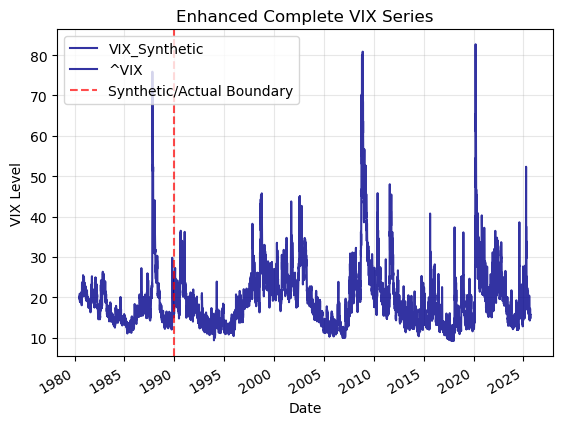


ENHANCED SYNTHETIC VIX PIPELINE COMPLETED SUCCESSFULLY
Final VIX series shape: (11362, 2)
Date range: 1980-07-02 to 2025-09-16


In [20]:
#!/usr/bin/env python
# coding: utf-8

# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from arch import arch_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy import stats
import xgboost as xgb
import warnings
import pandas_datareader.data as web

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


class EnhancedSyntheticVIX:
    """
    Enhanced synthetic VIX pipeline with improved accuracy and robustness.
    Key improvements:
    1. Enhanced feature engineering with volatility surface, macro, and cross-asset proxies.
    2. Stacking ensemble architecture for improved prediction blending.
    3. Walk-forward validation for robust out-of-sample performance evaluation.
    4. Externalized configuration for easier tuning and management.
    """

    def __init__(self, config):
        self.config = config
        self.models = {}
        self.scalers = {}
        self.feature_importance = None
        self.regime_model = None
        self.meta_model = Ridge(alpha=1.0)
        self.feature_names = None

    def _inspect_dataframe(self, df, stage=""):
        """Prints a detailed health report of a DataFrame."""
        print(f"\n--- DATA INSPECTION @ {stage} ---")
        print(f"Shape: {df.shape}")
        
        nan_report = df.isnull().sum() / len(df) * 100
        
        summary_data = []
        for col in df.columns:
            valid_data = df[col].dropna()
            start_date = valid_data.index.min() if not valid_data.empty else pd.NaT
            end_date = valid_data.index.max() if not valid_data.empty else pd.NaT
            summary_data.append({
                "Column": col,
                "NaN %": nan_report[col],
                "Start Date": start_date,
                "End Date": end_date
            })
        
        summary_df = pd.DataFrame(summary_data)
        
        summary_df['Start Date'] = pd.to_datetime(summary_df['Start Date'], errors='coerce').dt.date
        summary_df['End Date'] = pd.to_datetime(summary_df['End Date'], errors='coerce').dt.date
        
        summary_df = summary_df.sort_values(by="Start Date", ascending=False, na_position='last')
        print(summary_df.to_string())

        problem_cols = summary_df[summary_df['NaN %'] == 100]
        if not problem_cols.empty:
            print(f"\n!! CRITICAL WARNING: The following columns are 100% NaN and will cause data loss: {list(problem_cols['Column'])}")
        
        latest_start_date = summary_df['Start Date'].max()
        if pd.notna(latest_start_date):
                print(f"\n--> NOTE: The latest starting date among all columns is {latest_start_date}.")
                print("    This date will be the effective start date for the entire analysis after `dropna()`.")
        print("--- END INSPECTION ---\n")

    def download_data(self, ticker, start_date, end_date):
        """Downloads and performs quality checks on the financial data."""
        print(f"Downloading {ticker} data from {start_date} to {end_date}...")
        end_date_yf = (pd.to_datetime(end_date) + timedelta(days=1)).strftime('%Y-%m-%d')
        try:
            data = yf.download(ticker, start=start_date, end=end_date_yf, progress=False, auto_adjust=True)
            if data.empty:
                raise ValueError(f"No data returned for ticker {ticker}")
            
            data = data.dropna()
            if len(data) < 100:
                raise ValueError(f"Insufficient data for ticker {ticker} after dropping NaNs")
            return data.loc[:end_date]
        except Exception as e:
            raise type(e)(f"Failed to download or process data for {ticker}: {e}") from e

    def _calculate_range_volatility(self, ohlc_df, window=21):
        log_ho = np.log(ohlc_df['High'] / ohlc_df['Open'])
        log_lo = np.log(ohlc_df['Low'] / ohlc_df['Open'])
        log_co = np.log(ohlc_df['Close'] / ohlc_df['Open'])
        log_oc = np.log(ohlc_df['Open'] / ohlc_df['Close'].shift(1))
        k = 0.34 / (1.34 + (window + 1) / (window - 1))
        sigma_sq_oc = (log_oc**2).rolling(window=window).mean()
        sigma_sq_co = (log_co**2).rolling(window=window).mean()
        sigma_sq_hl = ((log_ho - log_lo)**2).rolling(window=window).mean()
        sigma_sq = sigma_sq_oc + k * sigma_sq_co + (1 - k) * sigma_sq_hl
        realized_vol = np.sqrt(sigma_sq) * np.sqrt(252) * 100
        return realized_vol

    def calculate_enhanced_garch_volatility(self, returns):
        print("Fitting enhanced GARCH model...")
        returns_squeezed = returns.squeeze()
        returns_clean = returns_squeezed.dropna()
        if returns_clean.empty or returns_clean.std() < 1e-9:
            return returns_squeezed.rolling(21).std() * np.sqrt(252) * 100
        z_scores = np.abs(stats.zscore(returns_clean))
        returns_clean = returns_clean[z_scores < 4]
        if len(returns_clean) < 100:
            return returns_squeezed.rolling(21).std() * np.sqrt(252) * 100
        try:
            models_to_try = [{'vol': 'GARCH', 'p': 1, 'q': 1}, {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1}, {'vol': 'GJR-GARCH', 'p': 1, 'o': 1, 'q': 1}]
            best_model, best_aic = None, np.inf
            for model_spec in models_to_try:
                try:
                    model = arch_model(returns_clean * 100, **model_spec, dist='skewt')
                    result = model.fit(disp='off', show_warning=False)
                    if result.aic < best_aic:
                        best_aic, best_model = result.aic, result
                except Exception: continue
            if best_model is None:
                return returns_squeezed.rolling(21).std() * np.sqrt(252) * 100
            vol_series = pd.Series(index=returns_squeezed.index, dtype=float)
            vol_series.loc[returns_clean.index] = best_model.conditional_volatility * np.sqrt(252)
            return vol_series.fillna(method='ffill').fillna(method='bfill')
        except Exception as e:
            print(f"GARCH model failed: {e}. Using rolling volatility.")
            return returns_squeezed.rolling(21).std() * np.sqrt(252) * 100

    def fit_regime_switching_model(self, returns):
        print("Fitting enhanced regime switching model...")
        returns_squeezed = returns.squeeze()
        try:
            returns_clean = returns_squeezed.dropna()
            if len(returns_clean) < 200: return None
            returns_clean.index = pd.to_datetime(returns_clean.index)
            for k in [2, 3, 4]:
                try:
                    model = MarkovRegression(returns_clean, k_regimes=k, trend='c', switching_variance=True)
                    result = model.fit(disp=False, maxiter=200)
                    if hasattr(result, 'smoothed_marginal_probabilities'): return result
                except Exception: continue
            return None
        except Exception as e:
            print(f"Regime switching model failed: {e}")
            return None

    def _analyze_and_engineer_features(self, df):
        """Analyzes feature redundancy and engineers new interaction features."""
        print("\n--- Step 2a: Feature Analysis & Engineering ---")
        
        # --- Correlation Analysis for Redundancy ---
        # Select only numeric columns for correlation matrix
        numeric_df = df.select_dtypes(include=np.number)
        corr_matrix = numeric_df.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        threshold = self.config['features']['correlation_threshold']
        
        print(f"Analyzing for feature correlations above {threshold}...")
        high_corr_found = False
        for column in upper_tri.columns:
            high_corr_series = upper_tri[column][upper_tri[column] > threshold]
            if not high_corr_series.empty:
                high_corr_found = True
                for idx, value in high_corr_series.items():
                    print(f"  --> High Correlation: '{column}' and '{idx}' ({value:.2f})")
        
        if not high_corr_found:
            print("  --> No highly correlated feature pairs found.")

        # --- Advanced Feature Engineering (Interaction Terms) ---
        print("Engineering new interaction features...")
        engineered_count = 0
        if 'GARCH_vol' in df.columns and 'Credit_Spread_Level' in df.columns:
            df['GARCH_x_CreditSpread'] = df['GARCH_vol'] * df['Credit_Spread_Level']
            print("  --> Created 'GARCH_x_CreditSpread'")
            engineered_count += 1
            
        if 'GARCH_vol' in df.columns and 'Yield_Curve_Slope' in df.columns:
            df['GARCH_x_YieldCurve'] = df['GARCH_vol'] * df['Yield_Curve_Slope']
            print("  --> Created 'GARCH_x_YieldCurve'")
            engineered_count += 1

        if 'GARCH_vol' in df.columns and 'MOVE_Level' in df.columns:
            df['Equity_vs_Bond_Vol_Ratio'] = df['GARCH_vol'] / (df['MOVE_Level'] + 1e-6)
            print("  --> Created 'Equity_vs_Bond_Vol_Ratio'")
            engineered_count += 1
        
        if engineered_count == 0:
            print("  --> No interaction features could be engineered with available data.")
            
        return df

    def create_enhanced_features(self, sp500_ohlc, garch_vol, external_data, actual_vix=None):
        """Enhanced feature engineering with volatility surface, macro and cross-asset proxies."""
        market_returns = sp500_ohlc['Close'].pct_change()
        
        df = pd.DataFrame({
            'Market_Return': market_returns.squeeze(),
            'GARCH_vol': garch_vol.squeeze()
        })
        
        if actual_vix is not None:
            df = df.join(actual_vix.squeeze().rename('y'), how='inner')

        # --- Standard Features ---
        df['GARCH_vol_lag1'] = df['GARCH_vol'].shift(1)
        df['Return_lag1'] = df['Market_Return'].shift(1)
        windows = self.config['features']['windows']
        for window in windows:
            df[f'Realized_Vol_{window}d'] = df['Market_Return'].shift(1).rolling(window=window).std() * np.sqrt(252) * 100
            df[f'Rolling_Skew_{window}d'] = df['Market_Return'].shift(1).rolling(window=window).skew()
            df[f'Rolling_Kurt_{window}d'] = df['Market_Return'].shift(1).rolling(window=window).kurt()
        df['Vol_Term_Structure'] = df['Realized_Vol_5d'] - df['Realized_Vol_21d']
        df['Vol_of_Vol'] = df['GARCH_vol'].rolling(21).std()
        df['YZ_Volatility'] = self._calculate_range_volatility(sp500_ohlc, window=self.config['features']['yz_vol_window'])
        
        # --- Conditionally Added External Features ---
        if external_data.get('^MOVE') is not None and not external_data['^MOVE'].empty:
            df['MOVE_Level'] = external_data['^MOVE']['Close'].reindex(df.index, method='ffill')
        if external_data.get('^GVZ') is not None and not external_data['^GVZ'].empty:
            df['GVZ_Level'] = external_data['^GVZ']['Close'].reindex(df.index, method='ffill')
        if external_data.get('^EVZ') is not None and not external_data['^EVZ'].empty:
            df['EVZ_Level'] = external_data['^EVZ']['Close'].reindex(df.index, method='ffill')
        if external_data.get('BAMLC0A4CBBBEY') is not None and not external_data['BAMLC0A4CBBBEY'].empty:
            df['Credit_Spread_Level'] = external_data['BAMLC0A4CBBBEY'].reindex(df.index, method='ffill')
        if external_data.get('T10Y2Y') is not None and not external_data['T10Y2Y'].empty:
            df['Yield_Curve_Slope'] = external_data['T10Y2Y'].reindex(df.index, method='ffill').shift(1)
        if external_data.get('CPIAUCSL') is not None and not external_data['CPIAUCSL'].empty:
            df['Inflation_YoY'] = external_data['CPIAUCSL'].pct_change(12).reindex(df.index, method='ffill').shift(1)
        
        if hasattr(self, 'regime_model') and self.regime_model is not None:
            try:
                regime_probs = pd.DataFrame(self.regime_model.smoothed_marginal_probabilities, index=self.regime_model.model.data.orig_endog.index)
                for i in range(regime_probs.shape[1]):
                    df[f'Regime_{i}_Prob'] = regime_probs[i].reindex(df.index, method='ffill')
            except Exception as e:
                print(f"Error creating regime features: {e}")

        df = self._analyze_and_engineer_features(df)
        
        feature_cols = [col for col in df.columns if col not in ['Market_Return', 'y']]
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        self._inspect_dataframe(df, "Before Feature Cleaning (dropna)")
        
        if 'y' in df.columns:
            combined = df.dropna()
            self.feature_names = [col for col in feature_cols if col in combined.columns]
            return combined[self.feature_names], combined['y']
        else:
            clean_df = df.dropna()
            self.feature_names = [col for col in feature_cols if col in clean_df.columns]
            return clean_df[self.feature_names]

    def create_enhanced_models(self):
        return {'ridge': Ridge(**self.config['models']['ridge']), 'lasso': Lasso(**self.config['models']['lasso']), 'elastic': ElasticNet(**self.config['models']['elastic']), 'rf': RandomForestRegressor(**self.config['models']['rf']), 'xgb': xgb.XGBRegressor(**self.config['models']['xgb']), 'gbr': GradientBoostingRegressor(**self.config['models']['gbr']), 'mlp': MLPRegressor(**self.config['models']['mlp'])}
    def train_models(self, X_train, y_train):
        print("Training stacking ensemble...")
        self.models = self.create_enhanced_models()
        self.scalers['standard'] = StandardScaler().fit(X_train); self.scalers['robust'] = RobustScaler().fit(X_train)
        scaling_map = {'ridge': 'standard', 'lasso': 'standard', 'elastic': 'standard', 'rf': None, 'xgb': None, 'gbr': None, 'mlp': 'robust'}
        meta_features = pd.DataFrame(index=X_train.index, columns=self.models.keys(), dtype=float)
        tscv = TimeSeriesSplit(n_splits=self.config['validation']['stacking_n_splits'])
        print("  Generating out-of-fold predictions for meta-model...")
        for train_idx, val_idx in tscv.split(X_train):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_train_fold = y_train.iloc[train_idx]
            for name, model_instance in self.create_enhanced_models().items():
                temp_model = model_instance
                scaler_type = scaling_map[name]
                if scaler_type == 'standard':
                    scaler = StandardScaler().fit(X_train_fold)
                    X_train_fold_scaled, X_val_fold_scaled = scaler.transform(X_train_fold), scaler.transform(X_val_fold)
                elif scaler_type == 'robust':
                    scaler = RobustScaler().fit(X_train_fold)
                    X_train_fold_scaled, X_val_fold_scaled = scaler.transform(X_train_fold), scaler.transform(X_val_fold)
                else: X_train_fold_scaled, X_val_fold_scaled = X_train_fold, X_val_fold
                temp_model.fit(X_train_fold_scaled, y_train_fold)
                meta_features.loc[X_val_fold.index, name] = temp_model.predict(X_val_fold_scaled)
        print("  Training final base models on full training data...")
        X_train_std, X_train_rob = self.scalers['standard'].transform(X_train), self.scalers['robust'].transform(X_train)
        for name, model in self.models.items():
            if scaling_map[name] == 'standard': model.fit(X_train_std, y_train)
            elif scaling_map[name] == 'robust': model.fit(X_train_rob, y_train)
            else: model.fit(X_train, y_train)
        if 'xgb' in self.models and not X_train.empty:
            self.feature_importance = pd.Series(self.models['xgb'].feature_importances_, index=self.feature_names).sort_values(ascending=False)
        meta_features_cleaned = meta_features.dropna()
        y_train_aligned = y_train.loc[meta_features_cleaned.index]
        print("  Training meta-model...")
        self.meta_model.fit(meta_features_cleaned, y_train_aligned)
    def get_individual_predictions(self, X):
        scaling_map = {'ridge': 'standard', 'lasso': 'standard', 'elastic': 'standard', 'rf': None, 'xgb': None, 'gbr': None, 'mlp': 'robust'}
        predictions = {}
        for name, model in self.models.items():
            scaler_type = scaling_map[name]
            if scaler_type == 'standard': X_scaled = self.scalers['standard'].transform(X)
            elif scaler_type == 'robust': X_scaled = self.scalers['robust'].transform(X)
            else: X_scaled = X
            predictions[name] = model.predict(X_scaled)
        return pd.DataFrame(predictions, index=X.index)
    def create_blended_prediction(self, X):
        individual_preds_df = self.get_individual_predictions(X)
        blended_pred = self.meta_model.predict(individual_preds_df)
        return blended_pred, individual_preds_df
    
    def synthetic_vix_pipeline(self):
        """Main pipeline implementing walk-forward validation."""
        
        pipeline_start = pd.to_datetime(self.config['dates']['pipeline_start'])
        backfill_start = pd.to_datetime(self.config['dates']['backfill_start'])
        data_start = backfill_start - pd.DateOffset(years=self.config['dates']['data_start_buffer_years'])
        test_end_date = pd.to_datetime(datetime.now().strftime('%Y-%m-%d'))
        
        print("=== ENHANCED SYNTHETIC VIX PIPELINE (STACKING + WALK-FORWARD) ===")
        
        print("\n--- Step 1: Data Collection & Pre-computation ---")
        sp500_price = self.download_data(self.config['tickers']['equity'], data_start, test_end_date)
        vix_data = self.download_data(self.config['tickers']['vix'], pipeline_start, test_end_date)['Close']
        print(f"--> CHECKPOINT: Base data loaded. S&P500 shape: {sp500_price.shape}, VIX shape: {vix_data.shape}")
        
        external_data = {}
        for ticker in self.config['tickers']['cross_asset_yf']:
            try:
                data = self.download_data(ticker, data_start, test_end_date)
                external_data[ticker] = data
            except Exception as e:
                print(f"WARNING: Could not download {ticker}. It will be excluded. Reason: {e}")

        fred_tickers = self.config['tickers']['macro_fred']
        try:
            fred_api_key = self.config.get('api_keys', {}).get('fred')
            if fred_api_key: print("Using FRED API Key for data download.")
            fred_data = web.DataReader(fred_tickers, 'fred', data_start, test_end_date, api_key=fred_api_key)
            for ticker in fred_tickers:
                series = fred_data.get(ticker)
                if series is None or series.dropna().empty:
                    print(f"WARNING: FRED ticker '{ticker}' contains no valid data. It will be excluded.")
                else:
                    external_data[ticker] = series.squeeze()
        except Exception as e:
            print(f"CRITICAL WARNING: Failed to download data from FRED. All macro features will be missing. Error: {e}")
        
        print(f"\n--> CHECKPOINT: External data collection complete. {len(external_data)} sources loaded.")
        for name, data in external_data.items():
             if data is not None and not data.empty:
                 print(f"    - {name}: Loaded data from {data.index.min().date()} to {data.index.max().date()}")

        sp500_returns = sp500_price['Close'].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        garch_vol = self.calculate_enhanced_garch_volatility(sp500_returns)
        self.regime_model = self.fit_regime_switching_model(sp500_returns)
        print("--> CHECKPOINT: GARCH and Regime models fitted.")

        print("\n--- Step 2: Feature Engineering (Full Dataset) ---")
        X_full, y_full = self.create_enhanced_features(sp500_price, garch_vol, external_data, vix_data)
        
        if y_full.empty:
            print("\nCRITICAL ERROR: No data remains after feature engineering and cleaning (`dropna`).")
            print("The inspector above shows the latest start date required by a feature. Data before this date is dropped.")
            print("Please check the download warnings and the inspector report.")
            return None
            
        print("\n--> CHECKPOINT: Feature engineering complete.")
        print(f"    Full feature matrix shape (X_full): {X_full.shape}")
        print(f"    Full target vector shape (y_full): {y_full.shape}")
        print(f"    Available data range after cleaning: {y_full.index.min().date()} to {y_full.index.max().date()}")
        
        config_train_end = pd.to_datetime(self.config['validation']['initial_train_end'])
        min_training_years = self.config['validation']['min_training_years']
        earliest_possible_train_end = y_full.index.min() + pd.DateOffset(years=min_training_years)
        current_train_end = max(config_train_end, earliest_possible_train_end)
        prediction_step = pd.DateOffset(years=self.config['validation']['prediction_step_years'])
        all_predictions, all_true_values = [], []
        print("\n--- Step 3: Walk-Forward Validation ---")
        if current_train_end >= y_full.index.max():
            print(f"\nWARNING: Not enough data for walk-forward validation.")
            return None
        fold_count = 0
        while current_train_end < y_full.index.max():
            fold_count += 1
            test_start = current_train_end + pd.Timedelta(days=1)
            test_end = current_train_end + prediction_step
            if test_end > y_full.index.max(): test_end = y_full.index.max()
            print(f"\n===== FOLD {fold_count} =====")
            print(f"Training window: {y_full.index.min().date()} to {current_train_end.date()}")
            print(f"Testing window:  {test_start.date()} to {test_end.date()}")
            X_train_current = X_full.loc[:current_train_end]; y_train_current = y_full.loc[:current_train_end]
            X_test_current = X_full.loc[test_start:test_end]; y_test_current = y_full.loc[test_start:test_end]
            print(f"  --> Fold Checkpoint: Train shape: {X_train_current.shape}, Test shape: {X_test_current.shape}")
            if X_test_current.empty: break
            self.train_models(X_train_current, y_train_current)
            blended_pred, _ = self.create_blended_prediction(X_test_current)
            all_predictions.append(pd.Series(blended_pred, index=y_test_current.index))
            all_true_values.append(y_test_current)
            current_train_end += prediction_step
        print(f"\n--> CHECKPOINT: Walk-forward loop finished. {len(all_predictions)} folds were successfully predicted.")
        print("\n--- Step 4: Final Evaluation of Out-of-Sample Results ---")
        if not all_predictions:
            print("\nERROR: Walk-forward validation loop produced no predictions.")
            return None
        final_preds, final_true = pd.concat(all_predictions), pd.concat(all_true_values)
        rmse = np.sqrt(mean_squared_error(final_true, final_preds))
        mae = mean_absolute_error(final_true, final_preds)
        correlation = np.corrcoef(final_true, final_preds)[0, 1]
        print(f"\nWALK-FORWARD ENSEMBLE TEST RESULTS:\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nCorrelation: {correlation:.4f}")
        if self.feature_importance is not None:
            print(f"\nTop 15 Features (from last training fold):\n{self.feature_importance.head(15)}")
        plt.figure(figsize=(16, 6)); plt.plot(final_true.index, final_true.values, label='Actual VIX', linewidth=2, color='black'); plt.plot(final_preds.index, final_preds.values, label='Enhanced Prediction (Out-of-Sample)', alpha=0.8, linewidth=2, color='red'); plt.title(f'Walk-Forward VIX Prediction vs. Actual (Correlation: {correlation:.3f}, RMSE: {rmse:.2f})'); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
        print("\n--- Step 5: Generate Final Synthetic VIX for Backfill Period ---")
        print("Retraining models on all available data for final backfill...")
        self.train_models(X_full, y_full)
        X_backfill = self.create_enhanced_features(sp500_price.loc[backfill_start:pipeline_start - pd.Timedelta(days=1)], garch_vol.loc[backfill_start:pipeline_start - pd.Timedelta(days=1)], external_data)
        print(f"--> CHECKPOINT: Backfill feature matrix shape: {X_backfill.shape}")
        if not X_backfill.empty:
            synthetic_pred, _ = self.create_blended_prediction(X_backfill)
            vix_synthetic = pd.Series(synthetic_pred, index=X_backfill.index, name='VIX_Synthetic')
            full_vix = pd.concat([vix_synthetic, vix_data])
        else:
            print("WARNING: No data available for backfill period after cleaning.")
            full_vix = vix_data
        full_vix.name = 'VIX_Enhanced'
        full_vix = full_vix.sort_index(); full_vix = full_vix[~full_vix.index.duplicated(keep='last')]
        plt.figure(figsize=(16, 8)); full_vix.plot(label='Enhanced VIX (Synthetic + Actual)', alpha=0.8, color='darkblue'); plt.axvline(pipeline_start, color='red', linestyle='--', alpha=0.7, label='Synthetic/Actual Boundary'); plt.title('Enhanced Complete VIX Series'); plt.ylabel('VIX Level'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()
        return full_vix

# ==============================================================================
# Main Execution Block
# ==============================================================================

def run_vix_pipeline():
    config = {
        'api_keys': {
            'fred': '856a3fcb406be3d3ab15dd7eed28ec7c'
        },
        'dates': {
            'data_start_buffer_years': 2,
            'pipeline_start': '1990-01-01',
            'backfill_start': '1980-01-01'
        },
        'tickers': {
            'equity': '^GSPC',
            'vix': '^VIX',
            # --- MODIFIED: Removed tickers with short histories ---
            'cross_asset_yf': [],
            # --- MODIFIED: Removed tickers with short histories ---
            'macro_fred': ['T10Y2Y', 'CPIAUCSL']
        },
        'features': {
            'windows': [5, 10, 21, 63, 126],
            'yz_vol_window': 21,
            'correlation_threshold': 0.90
        },
        'models': {
            'ridge': {'alpha': 5.0},
            'lasso': {'alpha': 0.005, 'max_iter': 2000},
            'elastic': {'alpha': 0.01, 'l1_ratio': 0.5, 'max_iter': 2000},
            'rf': {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1},
            'xgb': {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1},
            'gbr': {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'random_state': 42},
            'mlp': {'hidden_layer_sizes': [128, 64, 32], 'activation': 'relu', 'solver': 'adam', 'max_iter': 1000, 'random_state': 42, 'alpha': 0.001, 'early_stopping': True, 'validation_fraction': 0.1}
        },
        'validation': {
            'initial_train_end': '2007-12-31',
            'prediction_step_years': 1,
            'stacking_n_splits': 5,
            'min_training_years': 5
        }
    }

    try:
        vix_generator = EnhancedSyntheticVIX(config)
        final_vix_series = vix_generator.synthetic_vix_pipeline()
        
        print("\n" + "="*70)
        if final_vix_series is not None and not final_vix_series.empty:
            print("ENHANCED SYNTHETIC VIX PIPELINE COMPLETED SUCCESSFULLY")
            print(f"Final VIX series shape: {final_vix_series.shape}")
            print(f"Date range: {final_vix_series.index.min().date()} to {final_vix_series.index.max().date()}")
        else:
            print("PIPELINE FINISHED, BUT NO FINAL SERIES WAS GENERATED DUE TO DATA LIMITATIONS.")
        print("="*70)
        
    except Exception as e:
        print(f"\nPIPELINE FAILED WITH ERROR: {e}")
        import traceback
        traceback.print_exc()

# Run the pipeline
run_vix_pipeline()